<div>
 
  <b>Escuela Politécnica Nacional</b><br>
  <small>Facultad de Ingeniería de Sistemas</small><br>
  <small>Ingeniería en Ciencias de la Computación</small>
 
  <hr>
 
  <div style="display:flex; justify-content:space-between;">
    <div>
      Estudiante: <b>Mateo Cumbal</b><br>
      Fecha: <b>2026-05-03</b>
    </div>
    <div style="text-align:right;">
      Asignatura: <b>Recuperación de la Información</b><br>
      Paralelo: <b>GR1CC</b>
    </div>
  </div>
 
  <hr>
 
  <div style="text-align:center;">
    <h1><b>Ejercicio 4 — Modelo Probabilístico</b></h1>
  </div>
 
</div>

Este laboratorio compara dos modelos de recuperación de información sobre el corpus **Gutenberg 1000**:

- **TF-IDF + similitud coseno** — modelo vectorial clásico
- **BM25** — modelo probabilístico que añade normalización por longitud de documento

El objetivo es entender en qué difieren sus rankings y por qué BM25 suele ser más preciso en la práctica.

## Imports

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer

sys.path.append("../")
import libreria as ir

## Función de tokenización

Normaliza el texto: minúsculas, elimina puntuación básica y el BOM (`\ufeff`) que algunos
archivos UTF-8 incluyen al inicio y que contaminaría el vocabulario.

In [2]:
def tokenize(text: str) -> list:
    """Convierte un texto en lista de tokens normalizados."""
    return text.lower().replace(".", "").replace(",", "").replace("\ufeff", "").split()

---
## Parte 0 — Carga del corpus

In [3]:
corpus_gutenberg = ir.load_corpus("../corpus")
print(f"Libros cargados: {len(corpus_gutenberg)}")

Corpus cargado: 1000 archivo(s) desde '../corpus'
Libros cargados: 1000


In [4]:
# Tokenizar todos los documentos y guardar los títulos en el mismo orden
docs_tok_gutenberg = [tokenize(doc) for doc in corpus_gutenberg.values()]
titulos = list(corpus_gutenberg.keys())

N = len(docs_tok_gutenberg)  # total de documentos

print(f"Ejemplo — doc[0] (primeros 10 tokens): {docs_tok_gutenberg[0][:10]}")

Ejemplo — doc[0] (primeros 10 tokens): ['the', 'project', 'gutenberg', 'ebook', 'of', 'the', 'house', 'of', 'the', 'whispering']


---
## Parte 1 — Cálculo de TF, DF, IDF y TF-IDF

Para visualizar los valores de TF y DF de forma manejable se trabaja sobre una **muestra de 10 documentos**.
El corpus completo (1000 libros, ~1.7M términos únicos) haría imposible cualquier visualización densa.

TF-IDF se calcula con sklearn sobre el corpus completo, aprovechando matrices sparse.

### 1.1 Term Frequency (TF)

$$TF(t, d) = \frac{\text{conteo de } t \text{ en } d}{\text{total de tokens en } d}$$

Se usa `Counter` para contar todos los términos de un documento en un solo recorrido
(mucho más eficiente que calcular el conteo de cada término por separado).

In [5]:
muestra_docs   = docs_tok_gutenberg[:10]
muestra_titulos = titulos[:10]

tf_muestra = []
for doc in muestra_docs:
    conteo = Counter(doc)       # conteo crudo de cada término en un solo recorrido
    total  = len(doc)
    tf_doc = {term: count / total for term, count in conteo.items()}
    tf_muestra.append(tf_doc)

print(f"Documentos en la muestra: {len(tf_muestra)}")

Documentos en la muestra: 10


### 1.2 Document Frequency (DF)

**DF(t)** es el número de documentos de la muestra que contienen el término `t`.
Se acumula iterando sobre los dicts de TF y usando `Counter.update()` con las keys de cada documento.

In [6]:
df_muestra = Counter()
for tf_doc in tf_muestra:
    df_muestra.update(tf_doc.keys())  # +1 por cada término que aparece en este doc

print(f"Términos únicos en la muestra: {len(df_muestra)}")
print(f"DF de 'the': {df_muestra['the']} / 10  (aparece en todos los docs)")

Términos únicos en la muestra: 85956
DF de 'the': 10 / 10  (aparece en todos los docs)


### 1.3 TF-IDF con sklearn (corpus completo)

Con 1000 libros y ~675k términos únicos (después de la tokenización de sklearn), construir
una matriz densa requeriría ~40 GB de RAM. sklearn usa matrices **sparse** (CSR) que
solo almacenan los valores distintos de cero — viables porque un libro solo usa una
fracción pequeña del vocabulario total.

> sklearn usa `log(N/df + 1) + 1` en lugar de `log(N/df)`, así que los valores
> no son idénticos a una implementación manual, pero el comportamiento es equivalente.

In [7]:
# sklearn espera strings, no listas de tokens → reconstruir desde los tokens ya limpios
corpus_limpio = [" ".join(doc) for doc in docs_tok_gutenberg]

vectorizer_gutenberg    = TfidfVectorizer()
matriz_tfidf_gutenberg  = vectorizer_gutenberg.fit_transform(corpus_limpio)

print(f"Shape de la matriz : {matriz_tfidf_gutenberg.shape}")
print(f"Elementos no-cero  : {matriz_tfidf_gutenberg.nnz:,}")
print(f"Densidad           : {matriz_tfidf_gutenberg.nnz / (matriz_tfidf_gutenberg.shape[0] * matriz_tfidf_gutenberg.shape[1]):.4%}")

Shape de la matriz : (1000, 675909)
Elementos no-cero  : 6,991,402
Densidad           : 1.0344%


### 1.4 Visualización en DataFrame

Se muestran los **5 términos más frecuentes** (DF alto → IDF bajo → poco discriminativos)
y los **5 más raros** (DF bajo → IDF alto → muy discriminativos) de la muestra.

Los términos con `idf = NaN` son tokens con puntuación que sklearn descarta en su propia
tokenización (`engine;`, `fairness;`) — evidencia de que la tokenización básica genera ruido.

In [8]:
# Selección de términos: 5 más comunes + 5 más raros
lista_terminos = df_muestra.most_common()[-5:] + df_muestra.most_common(5)
terminos_df    = [tupla[0] for tupla in lista_terminos]

filas = []
for term in terminos_df:
    fila       = {"término": term, "df": df_muestra[term]}
    idx        = vectorizer_gutenberg.vocabulary_.get(term)
    fila["idf"] = vectorizer_gutenberg.idf_[idx] if idx is not None else None
    for i, tf_doc in enumerate(tf_muestra):
        fila[f"tf_doc{i}"] = tf_muestra[i].get(term, 0)
    filas.append(fila)

df_visualizacion = pd.DataFrame(filas).set_index("término")
df_visualizacion

,df,idf,tf_doc0,tf_doc1,tf_doc2,tf_doc3,tf_doc4,tf_doc5,tf_doc6,tf_doc7,tf_doc8,tf_doc9
término,,,,,,,,,,,,
engine;,1,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000012
oscillator,1,7.215608,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000012
applicability,1,4.864232,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000012
fairness;,1,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000012
lithotinting--coarse,1,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000012
the,10,1.000000,0.054820,0.031485,0.092450,0.041948,0.043464,0.068255,0.064170,0.077340,0.057387,0.065256
project,10,1.000000,0.000735,0.000098,0.000413,0.000252,0.000922,0.005246,0.002738,0.001792,0.000492,0.000989
gutenberg,10,1.000000,0.000569,0.000066,0.000315,0.000182,0.000703,0.004045,0.000815,0.001386,0.000379,0.000756
ebook,10,1.000000,0.000105,0.000012,0.000059,0.000034,0.000132,0.000758,0.000391,0.000256,0.000071,0.000140


---
## Parte 2 — Ranking de documentos con TF-IDF

Dado un query, se construye su vector TF-IDF usando el mismo vocabulario aprendido
y se calcula la **similitud coseno** contra cada documento de la colección.

Como sklearn normaliza los vectores a longitud 1, el producto punto matricial
equivale directamente a la similitud coseno — sin necesidad de dividir por las normas.

In [9]:
def buscar_gutenberg(consulta: str, top_k: int = 5) -> pd.DataFrame:
    """Rankea documentos por similitud coseno TF-IDF dado un query."""
    vector_consulta = vectorizer_gutenberg.transform([consulta])

    # Producto punto = similitud coseno (vectores ya normalizados por sklearn)
    scores = (matriz_tfidf_gutenberg @ vector_consulta.T).toarray().flatten()

    rank  = np.argsort(scores)[-top_k:][::-1]
    filas = [{"título": titulos[i], "score": scores[i]} for i in rank]
    return pd.DataFrame(filas)

In [10]:
buscar_gutenberg("mystery and detective", top_k=10)

,título,score
0,"19929_Cad Metti, The Female Detective Strategi...",0.169106
1,76_Adventures of Huckleberry Finn.txt,0.160393
2,"53545_Canadian Battlefields, and Other Poems.txt",0.156478
3,10380_Bible Stories and Religious Classics.txt,0.154794
4,4196_Diary of Samuel Pepys — Volume 71 January...,0.153131
5,51252_The Book of the Thousand Nights and a Ni...,0.152886
6,35674_Walks and Words of Jesus A Paragraph Har...,0.148228
7,53254_The Book of the Thousand Nights and a Ni...,0.147969
8,"56992_Stephen H. Branch's Alligator, Vol. 1 no...",0.140286
9,75186_A literal translation of the Saxon chron...,0.139860


---
## Parte 3 — Ranking con BM25

BM25 mejora sobre TF-IDF en dos aspectos clave:
1. **Saturación del TF** — un término que aparece 100 veces no vale 100× más que uno que aparece 10 veces
2. **Normalización por longitud** — documentos más largos no tienen ventaja automática

$$BM25(d, q) = \sum_{t \in q} IDF(t) \cdot \frac{TF(t,d) \cdot (k_1 + 1)}{TF(t,d) + k_1 \cdot \left(1 - b + b \cdot \frac{|d|}{avgdl}\right)}$$

Parámetros estándar: `k1 = 1.2` (saturación), `b = 0.75` (peso de la normalización por longitud).

In [11]:
# Longitud de cada documento y promedio de la colección
doc_lengths = [len(doc) for doc in docs_tok_gutenberg]
avgdl       = np.mean(doc_lengths)

print(f"Longitud promedio de documento: {avgdl:,.0f} tokens")

Longitud promedio de documento: 74,996 tokens


In [12]:
# TF crudo (sin normalizar) — BM25 maneja la normalización por longitud internamente
tf_bm25 = [Counter(doc) for doc in docs_tok_gutenberg]

In [13]:
# DF sobre el corpus completo
df_bm25 = Counter()
for tf_doc in tf_bm25:
    df_bm25.update(tf_doc.keys())

# IDF de BM25 — penaliza términos comunes y bonifica los raros
# La fórmula es más suave que log(N/df): nunca llega a 0 ni a valores negativos
idf_bm25 = {
    term: np.log((N - df + 0.5) / (df + 0.5) + 1)
    for term, df in df_bm25.items()
}

print(f"IDF de 'the' (aparece en todos los docs): {idf_bm25['the']:.6f}")

IDF de 'the' (aparece en todos los docs): 0.000500


In [14]:
k1 = 1.2   # saturación del TF: a mayor k1, más lento satura
b  = 0.75  # normalización por longitud: 0 = sin normalizar, 1 = normalización completa

In [15]:
def bm25_score(tf_doc: Counter, doc_length: int, query_terms: list) -> float:
    """Calcula el score BM25 de un documento dado un query."""
    score = 0.0
    for term in query_terms:
        if term not in idf_bm25:
            continue  # término fuera del vocabulario → aporte nulo
        tf_term = tf_doc.get(term, 0)
        score  += idf_bm25[term] * (tf_term * (k1 + 1)) / (
                    tf_term + k1 * (1 - b + b * (doc_length / avgdl))
                  )
    return score

In [16]:
def bm25_rank(consulta: str, top_k: int = 5) -> pd.DataFrame:
    """Rankea documentos por score BM25 dado un query."""
    query_terms = tokenize(consulta)
    scores      = [
        bm25_score(tf_bm25[i], doc_lengths[i], query_terms)
        for i in range(N)
    ]
    scores = np.array(scores)
    rank   = np.argsort(scores)[-top_k:][::-1]
    filas  = [{"título": titulos[i], "score": scores[i]} for i in rank]
    return pd.DataFrame(filas)

In [17]:
bm25_rank("mystery and detective", top_k=10)

,título,score
0,"19929_Cad Metti, The Female Detective Strategi...",5.757022
1,9297_The Orange-Yellow Diamond.txt,5.754140
2,46417_Prisoners in Devil's Bog A Skippy Dare M...,5.751186
3,6133_The Extraordinary Adventures of Arsène Lu...,5.703888
4,1651_The Mystery of Orcival.txt,5.702603
5,22225_Mary Louise in the Country.txt,5.683263
6,76339_The Roman hat mystery.txt,5.646173
7,244_A Study in Scarlet.txt,5.623791
8,4920_The Blind Spot.txt,5.598541
9,11043_Midnight.txt,5.540558


---
## Parte 4 — Comparación visual entre TF-IDF y BM25

Los scores de ambos modelos están en escalas distintas:
- **TF-IDF**: similitud coseno → siempre entre 0 y 1
- **BM25**: suma de pesos por término → sin límite superior

Para comparar visualmente se aplica **normalización min-max** a cada modelo,
llevando todos los scores al rango [0, 1].

In [18]:
query          = "mystery and detective"
resultado_tfidf = buscar_gutenberg(query, top_k=10)
resultado_bm25  = bm25_rank(query, top_k=10)

def normalizar(scores: np.ndarray) -> np.ndarray:
    """Normalización min-max al rango [0, 1]."""
    return (scores - scores.min()) / (scores.max() - scores.min())

resultado_tfidf["score_norm"] = normalizar(resultado_tfidf["score"].values)
resultado_bm25["score_norm"]  = normalizar(resultado_bm25["score"].values)

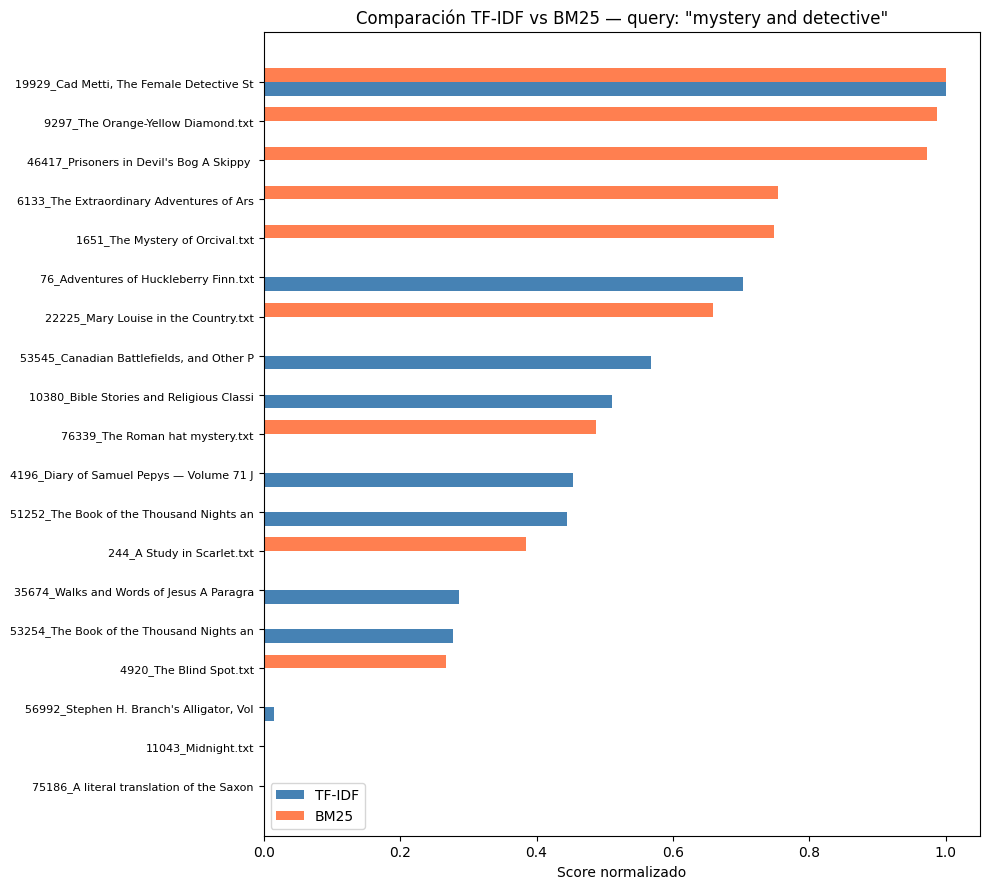

In [19]:
# Unión de los títulos de ambos rankings
titulos_union = list(set(resultado_tfidf["título"]) | set(resultado_bm25["título"]))

# Score normalizado por modelo (0 si el libro no apareció en ese ranking)
scores_tfidf, scores_bm25 = [], []
for t in titulos_union:
    fila_t = resultado_tfidf[resultado_tfidf["título"] == t]
    fila_b = resultado_bm25[resultado_bm25["título"] == t]
    scores_tfidf.append(fila_t["score_norm"].values[0] if len(fila_t) > 0 else 0)
    scores_bm25.append(fila_b["score_norm"].values[0]  if len(fila_b) > 0 else 0)

# Ordenar de mayor a menor score combinado
orden        = np.argsort([s1 + s2 for s1, s2 in zip(scores_tfidf, scores_bm25)])
titulos_union = [titulos_union[i]  for i in orden]
scores_tfidf  = [scores_tfidf[i]   for i in orden]
scores_bm25   = [scores_bm25[i]    for i in orden]
labels        = [t[:40] for t in titulos_union]

# Gráfico de barras horizontales agrupadas
x     = np.arange(len(titulos_union))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(x - width / 2, scores_tfidf, width, label="TF-IDF", color="steelblue")
ax.barh(x + width / 2, scores_bm25,  width, label="BM25",   color="coral")

ax.set_yticks(x)
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel("Score normalizado")
ax.set_title(f'Comparación TF-IDF vs BM25 — query: "{query}"')
ax.legend()
plt.tight_layout()
plt.show()

### Análisis de resultados

Los rankings difieren significativamente — solo **Cad Metti** aparece en el top de ambos modelos.

**Documentos que BM25 rankea alto y TF-IDF ignora** (Orange-Yellow Diamond, Prisoners in Devil's Bog, Arsène Lupin, A Study in Scarlet): son libros cortos o medianos con alta densidad de los términos del query. BM25 los favorece porque su normalización por longitud no penaliza documentos más cortos que sí son relevantes.

**Documentos que TF-IDF rankea alto y BM25 ignora** (Huckleberry Finn, Canadian Battlefields, Bible Stories): son libros muy largos donde los términos del query aparecen muchas veces simplemente por volumen, no por relevancia temática. TF-IDF los sube en el ranking por acumulación de ocurrencias; BM25 los penaliza por su longitud.

Esto ilustra el problema central que BM25 resuelve: en TF-IDF, un término que aparece 1000 veces en un documento largo puede pesar más que uno que aparece 50 veces en un documento corto y temáticamente enfocado, aunque el segundo sea más relevante.